In [1]:
# Install required engines silently
!pip install google-cloud-bigquery google-cloud-bigquery-storage pyarrow duckdb -q

In [2]:
import duckdb
import pyarrow as pa
from google.cloud import bigquery

# Initialize the BigQuery client pointing to your specific project
project_id = 'ecommerce-lakehouse-prod'
client = bigquery.Client(project=project_id)

# The Extraction Query (Leveraging your partition to save compute)

extract_query = """
    SELECT
        *
    FROM `ecommerce-lakehouse-prod.ecommerce_analytics.fct_session_features`

"""

print("Initiating BigQuery extraction via Storage API...")

# Execute and pipe directly into PyArrow (bypassing pandas completely)
df = client.query(extract_query).to_arrow()

print(f"Extraction successful.")
print(f"In-memory Arrow table shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Initialize the local DuckDB engine
con = duckdb.connect()

Initiating BigQuery extraction via Storage API...
Extraction successful.
In-memory Arrow table shape: 10,069,383 rows, 23 columns


--- FULL 10 MILLION SESSION DISTRIBUTION ---
                   Total_Sessions  Percentage (%)
user_segment                                     
3. Purchaser              4689028           46.57
2. Cart Abandoner         5380355           53.43


/tmp/ipykernel_165/398238357.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_165/398238357.py:35: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(


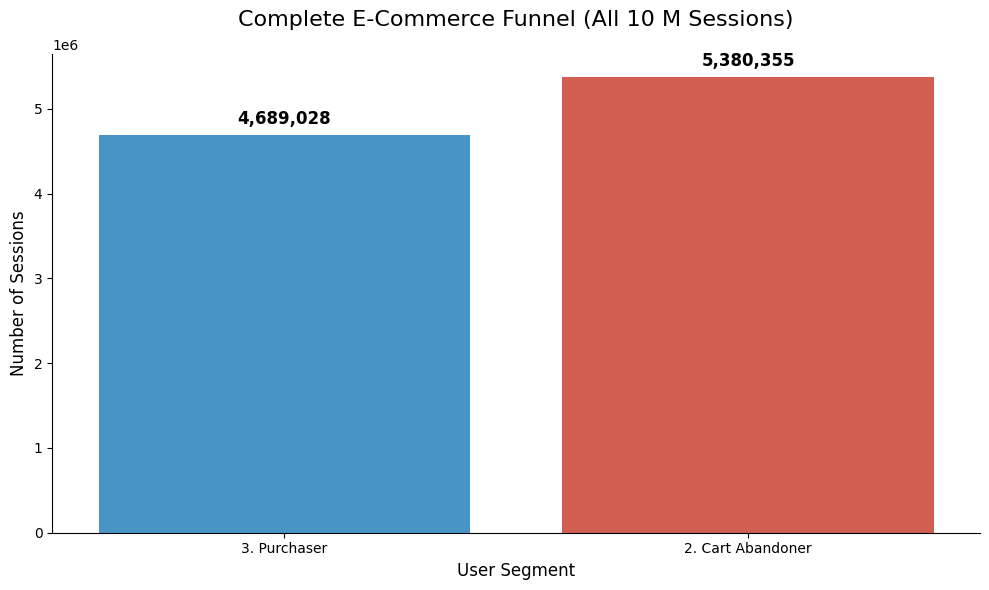

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let DuckDB query the PyArrow table directly in memory
query = """
    SELECT
        CASE
            WHEN has_purchase = 1 THEN '3. Purchaser'
            WHEN has_cart = 1 AND has_purchase = 0 THEN '2. Cart Abandoner'
            ELSE '1. View Only (Window Shopper)'
        END AS user_segment,
        COUNT(*) AS Total_Sessions
    FROM df
    GROUP BY 1
    ORDER BY user_segment DESC
"""

# Execute and pull ONLY the 3 summary rows into Pandas
summary_df = con.execute(query).df()

# Calculate percentages locally
total = summary_df['Total_Sessions'].sum()
summary_df['Percentage (%)'] = (summary_df['Total_Sessions'] / total * 100).round(2)
summary_df.set_index('user_segment', inplace=True)

print("="*60)
print("--- FULL 10 MILLION SESSION DISTRIBUTION ---")
print("="*60)
print(summary_df)
print("="*60)

# 3. Visualize the Complete Funnel
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=summary_df.index,
    y=summary_df['Total_Sessions'],
    palette=['#3498db', '#e74c3c', '#2ecc71']
)

plt.title('Complete E-Commerce Funnel (All 10 M Sessions)', fontsize=16, pad=20)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('User Segment', fontsize=12)

# Add exact numbers on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, weight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

# purchaser distribution 4,689,028


--- THE FRICTION DASHBOARD: PURCHASER BREAKDOWN ---
            Purchaser_Type  Total_Users  Percentage (%)
Hesitate Buyer (Purchased)      2475332           52.79
                Safe Buyer      2213696           47.21



/tmp/ipykernel_204/3536703335.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


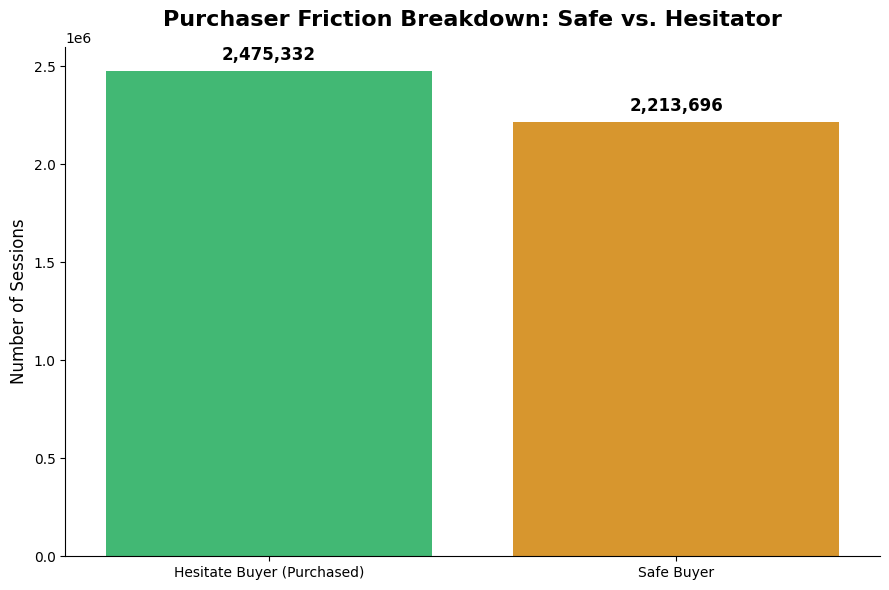

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Let DuckDB query the PyArrow table to isolate Purchaser statuses
query = """
    SELECT
        status AS Purchaser_Type,
        COUNT(*) AS Total_Users
    FROM df
    WHERE has_purchase = 1
    GROUP BY status
    ORDER BY Total_Users DESC
"""

# Execute and pull ONLY the summary rows into Pandas
purchaser_df = con.execute(query).df()

# 2. Calculate the exact percentages
total_purchasers = purchaser_df['Total_Users'].sum()
purchaser_df['Percentage (%)'] = (purchaser_df['Total_Users'] / total_purchasers * 100).round(2)

print("\n" + "="*60)
print("--- THE FRICTION DASHBOARD: PURCHASER BREAKDOWN ---")
print("="*60)
print(purchaser_df.to_string(index=False))
print("="*60 + "\n")

# 3. Visualize the Friction
plt.figure(figsize=(9, 6))

# Green for Safe, Orange for Friction
ax = sns.barplot(
    data=purchaser_df,
    x='Purchaser_Type',
    y='Total_Users',
    palette=['#2ecc71', '#f39c12']
)

plt.title('Purchaser Friction Breakdown: Safe vs. Hesitator', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('')

# Add exact numbers and formatting on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, weight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

# . The Margin Bleed: "Who are the 'Safe Buyers' we are accidentally giving discounts to?"


**The Volume: "We have 2,213,696 Safe Buyers."**

**The Profile (The "Who"):**

"These are hyper-decisive shoppers who exhibited zero friction. They add to cart in under 3 minutes, stick to 1 or 2 categories, and do not price-compare after carting."

**The Financial Impact (The Bleed):**

"Because they exhibit zero friction, giving them our standard discount costs us $X Million in unnecessary margin erosion."

In [ ]:
import pandas as pd

# ==========================================
# 1. THE EXTRACTION (DuckDB on PyArrow)
# ==========================================
query = """
    SELECT
        COUNT(*) AS total_safe_buyers,
        SUM(total_purchased_value) AS total_revenue
    FROM df
    WHERE status = 'Safe Buyer'
"""

# Execute and pull the raw numbers
safe_buyer_stats = con.execute(query).df()

# Extract variables
total_safe_buyers = safe_buyer_stats['total_safe_buyers'].iloc[0]
total_revenue = safe_buyer_stats['total_revenue'].iloc[0]

# Calculate the hypothetical bleed (Assuming a standard 10% blanket discount)
discount_rate = 0.10
margin_bleed = total_revenue * discount_rate

# ==========================================
# 2. THE EXECUTIVE PRESENTATION
# ==========================================
print("="*80)
print("EXECUTIVE SUMMARY: THE MARGIN BLEED ANALYSIS")
print("="*80 + "\n")

# Question 1: The Volume
print("1. THE VOLUME:")
print(f"   We have isolated {total_safe_buyers:,.0f} 'Safe Buyers' in the historical dataset.\n")

# Question 2: The Profile
print("2. THE PROFILE (THE 'WHO'):")
print("   These are hyper-decisive shoppers experiencing zero friction. They:")
print("   - Added their item to the cart in under 3 minutes.")
print("   - Kept tunnel-vision on 1 to 2 categories.")
print("   - Did not get distracted or price-compare after carting.")
print("   - Successfully checked out.\n")

# Question 3: The Financial Impact
print("3. THE FINANCIAL IMPACT (THE BLEED):")
print(f"   Total Organic Revenue from this cohort:   ${total_revenue:,.2f}")
print(f"   If we target them with a 10% discount:    -${margin_bleed:,.2f} (Pure Cash Burn)\n")

print("="*80)
print(f"ACTION REQUIRED: The ML Triage Engine will now shield these {total_safe_buyers:,.0f} users.")
print(f"By withholding discounts from this specific group, we instantly recover ${margin_bleed:,.2f} in profit margin.")
print("="*80)

EXECUTIVE SUMMARY: THE MARGIN BLEED ANALYSIS

1. THE VOLUME:
   We have isolated 2,213,696 'Safe Buyers' in the historical dataset.

2. THE PROFILE (THE 'WHO'):
   These are hyper-decisive shoppers experiencing zero friction. They:
   - Added their item to the cart in under 3 minutes.
   - Kept tunnel-vision on 1 to 2 categories.
   - Did not get distracted or price-compare after carting.
   - Successfully checked out.

3. THE FINANCIAL IMPACT (THE BLEED):
   Total Organic Revenue from this cohort:   $740,007,929.76
   If we target them with a 10% discount:    -$74,000,792.98 (Pure Cash Burn)

ACTION REQUIRED: The ML Triage Engine will now shield these 2,213,696 users.
By withholding discounts from this specific group, we instantly recover $74,000,792.98 in profit margin.


# cart abendors distribution 5,380,355


--- THE FRICTION DASHBOARD: ABANDONER BREAKDOWN ---
            Abandoner_Type  Total_Users  Percentage (%)
Hesitate Buyer (Abandoned)      3919454           72.85
            Window Shopper      1460901           27.15



/tmp/ipykernel_204/2856762035.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


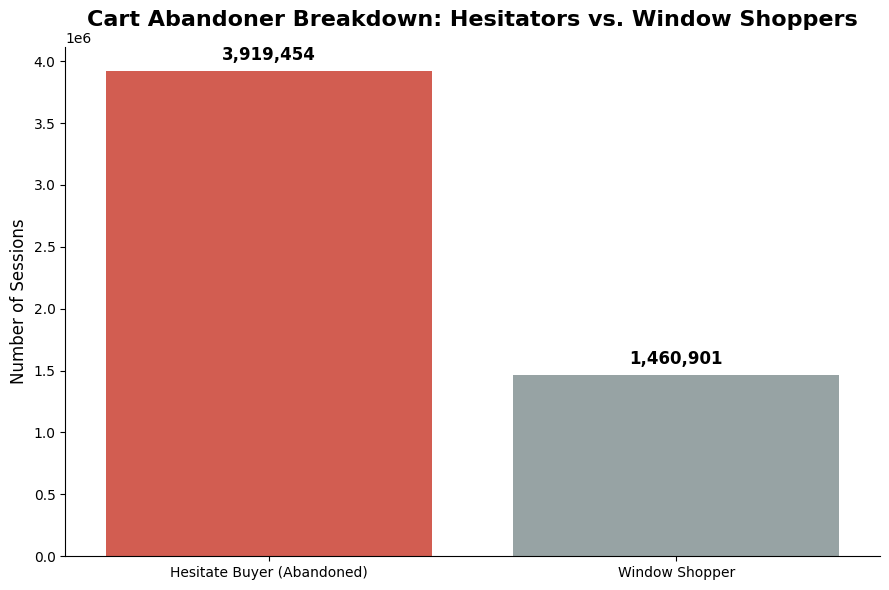

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Let DuckDB query the PyArrow table to isolate Abandoner statuses
query = """
    SELECT
        status AS Abandoner_Type,
        COUNT(*) AS Total_Users
    FROM df
    WHERE has_purchase = 0
    GROUP BY status
    ORDER BY Total_Users DESC
"""

# Execute and pull ONLY the summary rows into Pandas
abandoner_df = con.execute(query).df()

# 2. Calculate the exact percentages
total_abandoners = abandoner_df['Total_Users'].sum()
abandoner_df['Percentage (%)'] = (abandoner_df['Total_Users'] / total_abandoners * 100).round(2)

print("\n" + "="*60)
print("--- THE FRICTION DASHBOARD: ABANDONER BREAKDOWN ---")
print("="*60)
print(abandoner_df.to_string(index=False))
print("="*60 + "\n")

# 3. Visualize the Lost Revenue Pool
plt.figure(figsize=(9, 6))

# Red for the critical target (Hesitator), Grey for noise (Window Shopper)
ax = sns.barplot(
    data=abandoner_df,
    x='Abandoner_Type',
    y='Total_Users',
    palette=['#e74c3c', '#95a5a6']
)

plt.title('Cart Abandoner Breakdown: Hesitators vs. Window Shoppers', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('')

# Add exact numbers and formatting on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, weight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

--- MACRO SEGMENT DISTRIBUTION ---
       Macro_Segment  Total_Sessions  Percentage
       1. Safe Buyer         2213696        22.0
2. Hesitator (Total)         6394786        63.5
   3. Window Shopper         1460901        14.5



/tmp/ipykernel_204/3451295561.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


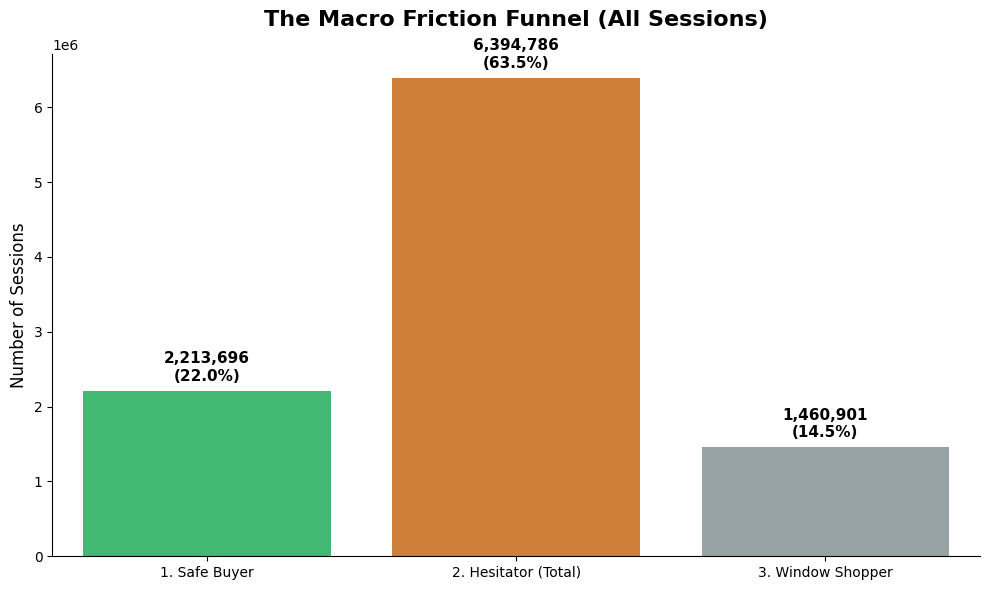

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. THE MACRO ROLLUP (DuckDB)
# ==========================================
# We use a CASE WHEN statement to fuse both Hesitator groups together
# while keeping Safe Buyers and Window Shoppers isolated.
query = """
    SELECT
        CASE
            WHEN status = 'Safe Buyer' THEN '1. Safe Buyer'
            WHEN status IN ('Hesitate Buyer (Purchased)', 'Hesitate Buyer (Abandoned)') THEN '2. Hesitator (Total)'
            WHEN status = 'Window Shopper' THEN '3. Window Shopper'
            ELSE 'Unknown'
        END AS Macro_Segment,
        COUNT(*) AS Total_Sessions
    FROM df
    GROUP BY 1
    ORDER BY Macro_Segment
"""

# Execute and pull into Pandas
macro_df = con.execute(query).df()

# Calculate percentages for the labels
total_sessions = macro_df['Total_Sessions'].sum()
macro_df['Percentage'] = (macro_df['Total_Sessions'] / total_sessions * 100).round(1)

print("="*60)
print("--- MACRO SEGMENT DISTRIBUTION ---")
print("="*60)
print(macro_df.to_string(index=False))
print("="*60 + "\n")

# ==========================================
# 2. THE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))

# Custom color mapping: Green (Good), Orange (Warning/Friction), Grey (Noise)
colors = ['#2ecc71', '#e67e22', '#95a5a6']

ax = sns.barplot(
    data=macro_df,
    x='Macro_Segment',
    y='Total_Sessions',
    palette=colors
)

plt.title('The Macro Friction Funnel (All Sessions)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('')

# Add exact numbers AND percentages on top of the bars
for p, perc in zip(ax.patches, macro_df['Percentage']):
    height = p.get_height()
    label_text = f'{int(height):,}\n({perc}%)'

    ax.annotate(label_text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, weight='bold', xytext=(0, 5), textcoords='offset points')

# Clean up the chart borders
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# If you don't have plotly installed in your colab, uncomment and run the line below:
# !pip install plotly

import pandas as pd
import plotly.express as px

# ==========================================
# 1. THE MACRO ROLLUP (DuckDB)
# ==========================================
query = """
    SELECT
        CASE
            WHEN status = 'Window Shopper' THEN '1. Window Shoppers (Top of Funnel)'
            WHEN status IN ('Hesitate Buyer (Purchased)', 'Hesitate Buyer (Abandoned)') THEN '2. Hesitators (Middle of Funnel)'
            WHEN status = 'Safe Buyer' THEN '3. Safe Buyers (Converted)'
            ELSE 'Unknown'
        END AS Funnel_Stage,
        COUNT(*) AS Total_Sessions
    FROM df
    GROUP BY 1
    ORDER BY Funnel_Stage ASC
"""

# Execute and pull into Pandas
funnel_df = con.execute(query).df()

# Calculate percentages for context
total_sessions = funnel_df['Total_Sessions'].sum()
funnel_df['Percentage'] = (funnel_df['Total_Sessions'] / total_sessions * 100).round(1)

print("Data aggregated successfully. Generating interactive funnel...")

# ==========================================
# 2. THE VISUALIZATION (Plotly)
# ==========================================
fig = px.funnel(
    funnel_df,
    x='Total_Sessions',
    y='Funnel_Stage',
    title='<b>The E-Commerce Friction Funnel</b>',
    color='Funnel_Stage',
    color_discrete_map={
        '1. Window Shoppers (Top of Funnel)': '#95a5a6',  # Grey (Noise)
        '2. Hesitators (Middle of Funnel)': '#e67e22',    # Orange (Friction/Drop-off point)
        '3. Safe Buyers (Converted)': '#2ecc71'           # Green (Clean Revenue)
    }
)

# Clean up the UI to make it executive-ready
fig.update_layout(
    title_x=0.5, # Center the title
    title_font_size=22,
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=14, font_family="Arial")
)

# Add custom text rendering inside the funnel blocks
fig.update_traces(
    texttemplate="%{y}<br><b>%{x:,.0f} Users</b>",
    textposition="inside",
    insidetextfont=dict(size=14, color='white')
)

fig.show()

Data aggregated successfully. Generating interactive funnel...


# The Rescue Target: "Who are the 'Hesitant Buyers' that actually need the 10% pop-up to convert?"

In [ ]:
import pandas as pd

# ==========================================
# 1. THE EXTRACTION (DuckDB on PyArrow)
# ==========================================
query = """
    SELECT
        status,
        COUNT(*) AS total_users,
        SUM(total_purchased_value) AS realized_revenue,
        SUM(net_cart_value) AS abandoned_value
    FROM df
    WHERE status IN ('Hesitate Buyer (Purchased)', 'Hesitate Buyer (Abandoned)')
    GROUP BY status
"""

hesitator_df = con.execute(query).df()

# Get the stats for the ones who bought
purchased_mask = hesitator_df['status'] == 'Hesitate Buyer (Purchased)'
hesitators_won = hesitator_df[purchased_mask]['total_users'].sum()
revenue_won = hesitator_df[purchased_mask]['realized_revenue'].sum()

# Get the stats for the ones who left
abandoned_mask = hesitator_df['status'] == 'Hesitate Buyer (Abandoned)'
hesitators_lost = hesitator_df[abandoned_mask]['total_users'].sum()
revenue_lost = hesitator_df[abandoned_mask]['abandoned_value'].sum()

total_hesitators = hesitators_won + hesitators_lost

# ==========================================
# 2. THE EXECUTIVE PRESENTATION (UPDATED UI)
# ==========================================
print("="*90)
print("EXECUTIVE SUMMARY: THE COMPLETE HESITANT BUYER COHORT")
print("="*90 + "\n")

print("1. THE TOTAL SCALE OF FRICTION:")
print(f"   We have a total of {total_hesitators:,.0f} users exhibiting 'Hesitant' behavior.\n")

print("2. THE SPLIT & FINANCIAL IMPACT (HEADCOUNT + MONEY):")
print(f"   Fought through friction (Purchased):  {hesitators_won:>10,.0f} users  |  Money Secured:  ${revenue_won:,.2f}")
print(f"   Gave up (Abandoned Cart):             {hesitators_lost:>10,.0f} users  |  Money Left:     ${revenue_lost:,.2f}  <-- (Rescue Target)")
print(f"   Current Hesitator Win Rate:           {(hesitators_won / total_hesitators * 100):.1f}%\n")

print("="*90)
print("DASHBOARD TAKEAWAY:")
print(f"This cohort represents {total_hesitators:,.0f} users who wanted to buy, but experienced friction.")
print(f"While we successfully forced ${revenue_won:,.2f} through the checkout, the UX/pricing")
print(f"issues caused us to leave ${revenue_lost:,.2f} sitting in abandoned carts.")
print("="*90)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

EXECUTIVE SUMMARY: THE COMPLETE HESITANT BUYER COHORT

1. THE TOTAL SCALE OF FRICTION:
   We have a total of 6,394,786 users exhibiting 'Hesitant' behavior.

2. THE SPLIT & FINANCIAL IMPACT (HEADCOUNT + MONEY):
   Fought through friction (Purchased):   2,475,332 users  |  Money Secured:  $987,025,274.41
   Gave up (Abandoned Cart):              3,919,454 users  |  Money Left:     $1,628,055,825.69  <-- (Rescue Target)
   Current Hesitator Win Rate:           38.7%

DASHBOARD TAKEAWAY:
This cohort represents 6,394,786 users who wanted to buy, but experienced friction.
While we successfully forced $987,025,274.41 through the checkout, the UX/pricing
issues caused us to leave $1,628,055,825.69 sitting in abandoned carts.


#  The Baseline: "How much money is actually sitting in abandoned carts?"


In [ ]:
import pandas as pd

# ==========================================
# ISOLATING THE ABANDONED REVENUE (DuckDB)
# ==========================================
query = """
    SELECT
        COUNT(*) AS total_abandoners,
        SUM(net_cart_value) AS total_abandoned_money
    FROM df
    WHERE status = 'Hesitate Buyer (Abandoned)'
"""

# Execute the query and pull into Pandas
rescue_target_df = con.execute(query).df()

# Extract the specific numbers
headcount = rescue_target_df['total_abandoners'].iloc[0]
abandoned_cash = rescue_target_df['total_abandoned_money'].iloc[0]

# ==========================================
# EXECUTIVE READOUT
# ==========================================
print("="*80)
print("THE RESCUE TARGET: ABANDONED HESITATORS")
print("="*80 + "\n")

print(f"Target Audience (Headcount):  {headcount:,.0f} highly-qualified abandoners")
print(f"Money Left on the Table:      ${abandoned_cash:,.2f}\n")

print("="*80)
print("STRATEGIC DIRECTIVE:")
print(f"These {headcount:,.0f} users represent ${abandoned_cash:,.2f} in unrealized revenue.")
print("This is the exact group we need to target with an exit-intent discount pop-up.")
print("="*80)

THE RESCUE TARGET: ABANDONED HESITATORS

Target Audience (Headcount):  3,919,454 highly-qualified abandoners
Money Left on the Table:      $1,628,055,825.69

STRATEGIC DIRECTIVE:
These 3,919,454 users represent $1,628,055,825.69 in unrealized revenue.
This is the exact group we need to target with an exit-intent discount pop-up.


#  The Noise: "Who are the 'Window Shoppers' we should ignore completely?"



In [ ]:
import pandas as pd

# ==========================================
# ISOLATING THE NOISE (DuckDB)
# ==========================================
# We calculate the raw headcount and what percentage of your total
# infrastructure they are chewing up.
query = """
    SELECT
        COUNT(*) AS total_window_shoppers,
        (COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df)) AS percentage_of_total
    FROM df
    WHERE status = 'Window Shopper'
"""

# Execute the query and pull into Pandas
noise_df = con.execute(query).df()

# Extract the numbers
noise_headcount = noise_df['total_window_shoppers'].iloc[0]
noise_percentage = noise_df['percentage_of_total'].iloc[0]

# ==========================================
# EXECUTIVE READOUT
# ==========================================
print("="*80)
print("THE NOISE: WINDOW SHOPPERS (EXCLUDE LIST)")
print("="*80 + "\n")

print("1. THE VOLUME:")
print(f"   Headcount: {noise_headcount:,.0f} users")
print(f"   Footprint: They consume {noise_percentage:.1f}% of our total site traffic.\n")

print("2. THE PROFILE (THE 'WHO'):")
print("   These are ultra-low intent browsers. They:")
print("   - Treat the cart like a Pinterest board/wishlist.")
print("   - Spend way over 5 minutes dawdling before carting.")
print("   - Browse 4+ random categories with no focus.")
print("   - Will not convert today, even with a discount.\n")

print("="*80)
print("STRATEGIC DIRECTIVE (DO NOT RETARGET):")
print(f"Exclude these {noise_headcount:,.0f} users from all paid retargeting campaigns (Meta/Google).")
print("Suppress this segment from the ML discount model to save compute costs.")
print("="*80)

THE NOISE: WINDOW SHOPPERS (EXCLUDE LIST)

1. THE VOLUME:
   Headcount: 1,460,901 users
   Footprint: They consume 14.5% of our total site traffic.

2. THE PROFILE (THE 'WHO'):
   These are ultra-low intent browsers. They:
   - Treat the cart like a Pinterest board/wishlist.
   - Spend way over 5 minutes dawdling before carting.
   - Browse 4+ random categories with no focus.
   - Will not convert today, even with a discount.

STRATEGIC DIRECTIVE (DO NOT RETARGET):
Exclude these 1,460,901 users from all paid retargeting campaigns (Meta/Google).
Suppress this segment from the ML discount model to save compute costs.


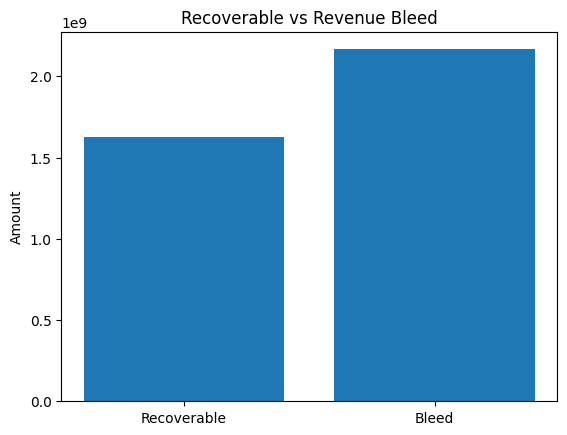

In [ ]:
import duckdb
import matplotlib.pyplot as plt

# execute SQL on dataframe 'df'
result = duckdb.query("""
SELECT
    SUM(recoverable_revenue) AS recoverable,
    SUM(revenue_bleed) AS bleed
FROM df
""").to_df()

# extract values
recoverable = result["recoverable"][0]
bleed = result["bleed"][0]

# plot
plt.bar(["Recoverable", "Bleed"], [recoverable, bleed])
plt.ylabel("Amount")
plt.title("Recoverable vs Revenue Bleed")
plt.show()

In [ ]:
import duckdb

query = """
SELECT
    SUM(net_cart_value) AS total_net_cart_value,
    SUM(total_purchased_value) AS total_purchased_value
FROM df
"""

result = duckdb.query(query).to_df()
result

,total_net_cart_value,total_purchased_value
0,4.656290e+09,1.727033e+09


In [ ]:
import duckdb

query = """
SELECT
    SUM(net_cart_value) AS total_net_cart_value,

FROM df
where has_purchase=0
"""

result = duckdb.query(query).to_df()
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_net_cart_value
0,2.166430e+09


In [ ]:
import duckdb

query = """
SELECT
    SUM(net_cart_value) AS total_net_cart_value,

FROM df
where status= 'Window Shopper'
"""

result = duckdb.query(query).to_df()
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_net_cart_value
0,5.383744e+08


In [ ]:
import duckdb
import pandas as pd

query = """
SELECT
    status,
    SUM(net_cart_value) AS total_value
FROM df
WHERE status IN ('Hesitate Buyer (Abandoned)', 'Window Shopper')
GROUP BY status
"""

data = duckdb.query(query).to_df()
data

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,status,total_value
0,Hesitate Buyer (Abandoned),1.628056e+09
1,Window Shopper,5.383744e+08


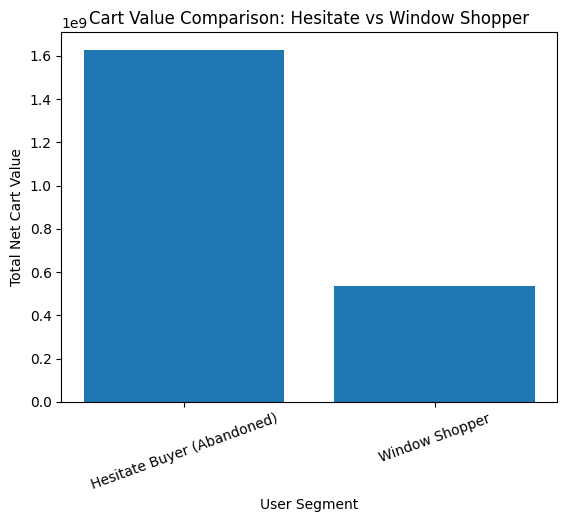

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(data['status'], data['total_value'])

plt.title('Cart Value Comparison: Hesitate vs Window Shopper')
plt.xlabel('User Segment')
plt.ylabel('Total Net Cart Value')

plt.xticks(rotation=20)

plt.show()

In [ ]:
import duckdb

query = """
SELECT
    status,
    SUM(total_purchased_value) AS total_revenue
FROM df
WHERE status IN ('Safe Buyer', 'Hesitate Buyer (Purchased)')
GROUP BY status
ORDER BY total_revenue DESC
"""

duckdb.query(query).to_df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,status,total_revenue
0,Hesitate Buyer (Purchased),9.870253e+08
1,Safe Buyer,7.400079e+08


In [ ]:
import duckdb
import pandas as pd

query = """
SELECT
    status,
    SUM(total_purchased_value) AS revenue
FROM df
WHERE status IN ('Safe Buyer', 'Hesitate Buyer (Purchased)')
GROUP BY status
"""

data = duckdb.query(query).to_df()

# Convert to billions for readability
data['revenue_bn'] = data['revenue'] / 1e9

data

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,status,revenue,revenue_bn
0,Hesitate Buyer (Purchased),9.870253e+08,0.987025
1,Safe Buyer,7.400079e+08,0.740008


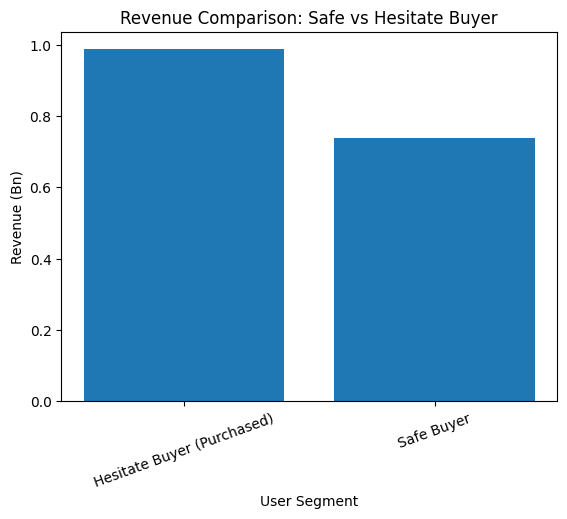

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(data['status'], data['revenue_bn'])

plt.title('Revenue Comparison: Safe vs Hesitate Buyer')
plt.xlabel('User Segment')
plt.ylabel('Revenue (Bn)')

plt.xticks(rotation=20)

plt.show()

In [ ]:
import duckdb

query = """
SELECT
    unique_categories_viewed,
    COUNT(*) AS session_count
FROM df
WHERE status = 'Window Shopper'
GROUP BY unique_categories_viewed
ORDER BY unique_categories_viewed
"""

duckdb.query(query).to_df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,unique_categories_viewed,session_count
0,1,794485
1,2,292710
2,3,126709
3,4,106825
4,5,55143
5,6,31139
6,7,18497
7,8,11621
8,9,7502
9,10,5093


In [ ]:
import duckdb

query = """
SELECT *
EXCLUDE (user_id, user_session)
FROM df
WHERE status = 'Window Shopper'
LIMIT 3
"""

duckdb.query(query).to_df()

,session_start_time,session_end_time,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value,views_before_cart,views_after_cart,unique_categories_viewed,time_to_cart_sec,is_premium_shopper,session_month,time_to_cart_formatted,status,protected_margin,recoverable_revenue,revenue_bleed,friction_revenue
0,2019-12-13 13:19:17+00:00,2019-12-13 13:23:18+00:00,1,1,0,2396.88,385.85,0.0,7,0,1,241,0,2019-12-01,0d:00h:04m:01s,Window Shopper,0.0,0.0,385.85,0.0
1,2019-11-14 11:33:02+00:00,2019-11-14 11:39:42+00:00,1,1,0,4699.65,333.86,0.0,7,6,1,274,0,2019-11-01,0d:00h:04m:34s,Window Shopper,0.0,0.0,333.86,0.0
2,2019-12-08 12:44:18+00:00,2019-12-08 12:52:18+00:00,1,1,0,13860.88,401.53,0.0,15,11,1,276,0,2019-12-01,0d:00h:04m:36s,Window Shopper,0.0,0.0,401.53,0.0


In [ ]:
query = """
SELECT
    CASE
        WHEN unique_categories_viewed = 1 THEN '1 Category'
        WHEN unique_categories_viewed <= 3 THEN '2–3 Categories'
        WHEN unique_categories_viewed <= 5 THEN '4–5 Categories'
        WHEN unique_categories_viewed <= 10 THEN '6–10 Categories'
        ELSE '10+ Categories'
    END AS category_bucket,

    COUNT(*) AS session_count

FROM df
WHERE status = 'Window Shopper'
GROUP BY category_bucket
ORDER BY category_bucket
"""

data = duckdb.query(query).to_df()
data

,category_bucket,session_count
0,1 Category,794485
1,10+ Categories,11177
2,2–3 Categories,419419
3,4–5 Categories,161968
4,6–10 Categories,73852


In [ ]:
data['percentage'] = (data['session_count'] / data['session_count'].sum()) * 100
data

,category_bucket,session_count,percentage
0,1 Category,794485,54.383220
1,10+ Categories,11177,0.765076
2,2–3 Categories,419419,28.709611
3,4–5 Categories,161968,11.086857
4,6–10 Categories,73852,5.055236


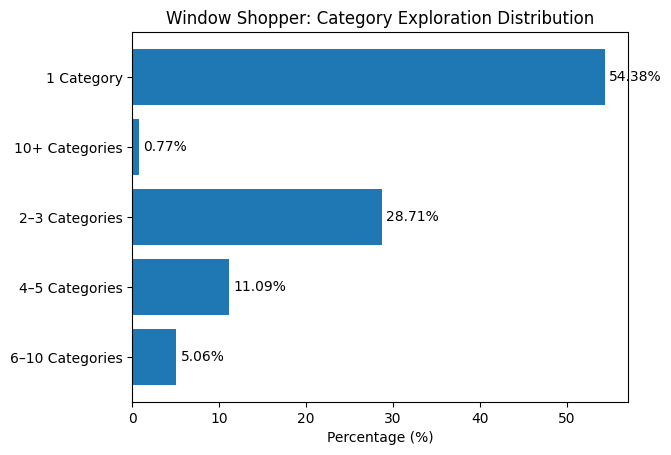

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.barh(data['category_bucket'], data['percentage'])

for i, v in enumerate(data['percentage']):
    plt.text(v + 0.5, i, f"{v:.2f}%", va='center')

plt.title('Window Shopper: Category Exploration Distribution')
plt.xlabel('Percentage (%)')

plt.gca().invert_yaxis()

plt.show()

In [5]:
import duckdb

In [13]:
import duckdb

query = """
WITH ViewBuckets AS (
    SELECT
        user_session,
        has_purchase,
        -- Hum raw views ko manual buckets mein daal rahe hain
        CASE
            WHEN views_before_first_cart <= 0 THEN '0_Views (Direct Cart)'
            WHEN views_before_first_cart IN (1, 2) THEN '1_to_2_Views'
            WHEN views_before_first_cart BETWEEN 3 AND 5 THEN '3_to_5_Views'
            WHEN views_before_first_cart BETWEEN 6 AND 10 THEN '6_to_10_Views'
            WHEN views_before_first_cart BETWEEN 11 AND 15 THEN '11_to_15_Views'
            ELSE '16_Plus_Views'
        END AS view_bucket
    FROM df
    -- Ensure hum sirf un logo ko dekh rahe hain jinhone cart mein kuch daala tha
    WHERE has_cart = 1
),

BucketAggregations AS (
    SELECT
        view_bucket,
        COUNT(DISTINCT user_session) AS user_count,
        SUM(has_purchase) AS total_purchasers,
        -- Total users mein se purchasers nikal do, toh abandoners bachenge
        COUNT(DISTINCT user_session) - SUM(has_purchase) AS total_abandoners
    FROM ViewBuckets
    GROUP BY view_bucket
),

TotalUsers AS (
    -- Total bheed calculate kar rahe hain percentage nikalne ke liye
    SELECT SUM(user_count) AS grand_total FROM BucketAggregations
)

SELECT
    b.view_bucket,
    b.user_count,
    -- Har bucket mein total bheed ka kitna percentage hai?
    ROUND((b.user_count * 100.0) / t.grand_total, 2) AS percentage_of_users,

    -- Inme se kitne log Safe/Hesitate (Purchasers) hain?
    b.total_purchasers,

    -- Inme se kitne log Hesitate/Window Shopper (Abandoners) hain?
    b.total_abandoners,

    -- THE ULTIMATE METRIC: Is bucket ka Conversion Rate kya hai?
    ROUND((b.total_purchasers * 100.0) / b.user_count, 2) AS conversion_rate_pct

FROM BucketAggregations b
CROSS JOIN TotalUsers t
ORDER BY
    -- Isko logical order mein sort karne ke liye
    CASE view_bucket
        WHEN '0_Views (Direct Cart)' THEN 1
        WHEN '1_to_2_Views' THEN 2
        WHEN '3_to_5_Views' THEN 3
        WHEN '6_to_10_Views' THEN 4
        WHEN '11_to_15_Views' THEN 5
        ELSE 6
    END;
"""

# Isko execute karo aur nateeja dekho
behavior_distribution = duckdb.query(query).to_df()
print(behavior_distribution)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

             view_bucket  user_count  percentage_of_users  total_purchasers  \
0  0_Views (Direct Cart)       93847                 0.93           48187.0   
1           1_to_2_Views     6390355                63.46         3188808.0   
2           3_to_5_Views     1859690                18.47          764379.0   
3          6_to_10_Views      954290                 9.48          376755.0   
4         11_to_15_Views      355864                 3.53          140922.0   
5          16_Plus_Views      415335                 4.12          169977.0   

   total_abandoners  conversion_rate_pct  
0           45660.0                51.35  
1         3201547.0                49.90  
2         1095311.0                41.10  
3          577535.0                39.48  
4          214942.0                39.60  
5          245358.0                40.93  


In [14]:
import duckdb

query = """
WITH BuyerBuckets AS (
    SELECT
        user_session,
        -- Views ki buckets (Groups)
        CASE
            WHEN views_before_first_cart <= 0 THEN '0_Views (Direct Cart)'
            WHEN views_before_first_cart IN (1, 2) THEN '1_to_2_Views'
            WHEN views_before_first_cart BETWEEN 3 AND 5 THEN '3_to_5_Views'
            WHEN views_before_first_cart BETWEEN 6 AND 10 THEN '6_to_10_Views'
            WHEN views_before_first_cart BETWEEN 11 AND 15 THEN '11_to_15_Views'
            ELSE '16_Plus_Views'
        END AS view_bucket
    FROM df
    -- THE FILTER: Sirf unko dekho jinhone cart banaya AUR purchase complete ki
    WHERE has_cart = 1 AND has_purchase = 1
),

BucketCounts AS (
    -- Har bucket mein kitne Buyers hain?
    SELECT
        view_bucket,
        COUNT(DISTINCT user_session) AS total_buyers
    FROM BuyerBuckets
    GROUP BY view_bucket
),

TotalBuyers AS (
    -- Percentage nikalne ke liye grand total
    SELECT SUM(total_buyers) AS grand_total FROM BucketCounts
)

SELECT
    b.view_bucket,
    b.total_buyers,
    -- Har bucket ka percentage out of Total Buyers
    ROUND((b.total_buyers * 100.0) / t.grand_total, 2) AS percentage_of_total_buyers

FROM BucketCounts b
CROSS JOIN TotalBuyers t
ORDER BY
    -- Logical sorting ke liye
    CASE view_bucket
        WHEN '0_Views (Direct Cart)' THEN 1
        WHEN '1_to_2_Views' THEN 2
        WHEN '3_to_5_Views' THEN 3
        WHEN '6_to_10_Views' THEN 4
        WHEN '11_to_15_Views' THEN 5
        ELSE 6
    END;
"""

# Run the query
buyer_distribution = duckdb.query(query).to_df()
print(buyer_distribution)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

             view_bucket  total_buyers  percentage_of_total_buyers
0  0_Views (Direct Cart)         48187                        1.03
1           1_to_2_Views       3188808                       68.01
2           3_to_5_Views        764379                       16.30
3          6_to_10_Views        376755                        8.03
4         11_to_15_Views        140922                        3.01
5          16_Plus_Views        169977                        3.62


In [15]:
import duckdb

query = """
WITH AbandonerBuckets AS (
    SELECT
        user_session,
        -- Views ki wahi same buckets comparison ke liye
        CASE
            WHEN views_before_first_cart <= 0 THEN '0_Views (Direct Cart)'
            WHEN views_before_first_cart IN (1, 2) THEN '1_to_2_Views'
            WHEN views_before_first_cart BETWEEN 3 AND 5 THEN '3_to_5_Views'
            WHEN views_before_first_cart BETWEEN 6 AND 10 THEN '6_to_10_Views'
            WHEN views_before_first_cart BETWEEN 11 AND 15 THEN '11_to_15_Views'
            ELSE '16_Plus_Views'
        END AS view_bucket
    FROM df
    -- THE FILTER: Cart banaya par kharida NAHI (The Abandoners)
    WHERE has_cart = 1 AND has_purchase = 0
),

BucketCounts AS (
    -- Har bucket mein kitne Abandoners hain?
    SELECT
        view_bucket,
        COUNT(DISTINCT user_session) AS total_abandoners
    FROM AbandonerBuckets
    GROUP BY view_bucket
),

TotalAbandoners AS (
    -- Percentage nikalne ke liye grand total
    SELECT SUM(total_abandoners) AS grand_total FROM BucketCounts
)

SELECT
    b.view_bucket,
    b.total_abandoners,
    -- Har bucket ka percentage out of Total Abandoners
    ROUND((b.total_abandoners * 100.0) / t.grand_total, 2) AS percentage_of_total_abandoners

FROM BucketCounts b
CROSS JOIN TotalAbandoners t
ORDER BY
    -- Logical sorting
    CASE view_bucket
        WHEN '0_Views (Direct Cart)' THEN 1
        WHEN '1_to_2_Views' THEN 2
        WHEN '3_to_5_Views' THEN 3
        WHEN '6_to_10_Views' THEN 4
        WHEN '11_to_15_Views' THEN 5
        ELSE 6
    END;
"""

# Run the query
abandoner_distribution = duckdb.query(query).to_df()
print(abandoner_distribution)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

             view_bucket  total_abandoners  percentage_of_total_abandoners
0  0_Views (Direct Cart)             45660                            0.85
1           1_to_2_Views           3201547                           59.50
2           3_to_5_Views           1095311                           20.36
3          6_to_10_Views            577535                           10.73
4         11_to_15_Views            214942                            3.99
5          16_Plus_Views            245358                            4.56
